## Quadrotor

Imports

In [1]:
import importlib
import numpy as np

# Trajopt imports --> pip install -e ~/ACL/trajopt
import trajopt; importlib.reload(trajopt)
from trajopt.core.trajectory_analyzer import TrajectoryAnalyzer
np.random.seed(0)  # for reproducibility

setup problem and run SCP

In [2]:
# create trajectroy analyzer object
mission = "mission.yaml"
model   = "trajopt/models/quadrotor_3dof.yaml"
method  = "method.yaml"

trajopt = TrajectoryAnalyzer(mission, model, method)

trajopt.solve()

problem configuration: 
------------------------------------------------------------
constraints:
  0: dynamics: type: dynamics
  1: initial_state: type: equality_bc
  2: state_limits: type: box
  3: final_state: type: equality_bc
  4: initial_control: type: equality_bc
  5: final_control: type: equality_bc
  6: control_rate_limit: type: control_rate_limit
  7: max_thrust: type: max_norm_cone
  8: min_thrust: type: nonconvex_inequality
  9: obstacle: type: nonconvex_inequality

costs:
  0: min_time: min_time
------------------------------------------------------------


nondim scales: 
------------------------------------------------------------
state scales: [1. 1. 1. 1. 1. 1.]
control scales: [1. 1. 1.]
time scale: 1.0
------------------------------------------------------------


subproblem stats:
------------------------------------------------------------
total number of parameters: 3201
----------------------------------------------------------------------------------------------

In [3]:
data = trajopt.analyze(analysis_type="standalone", compute_iters=True)

Saved 9 figures to plots/standalone/


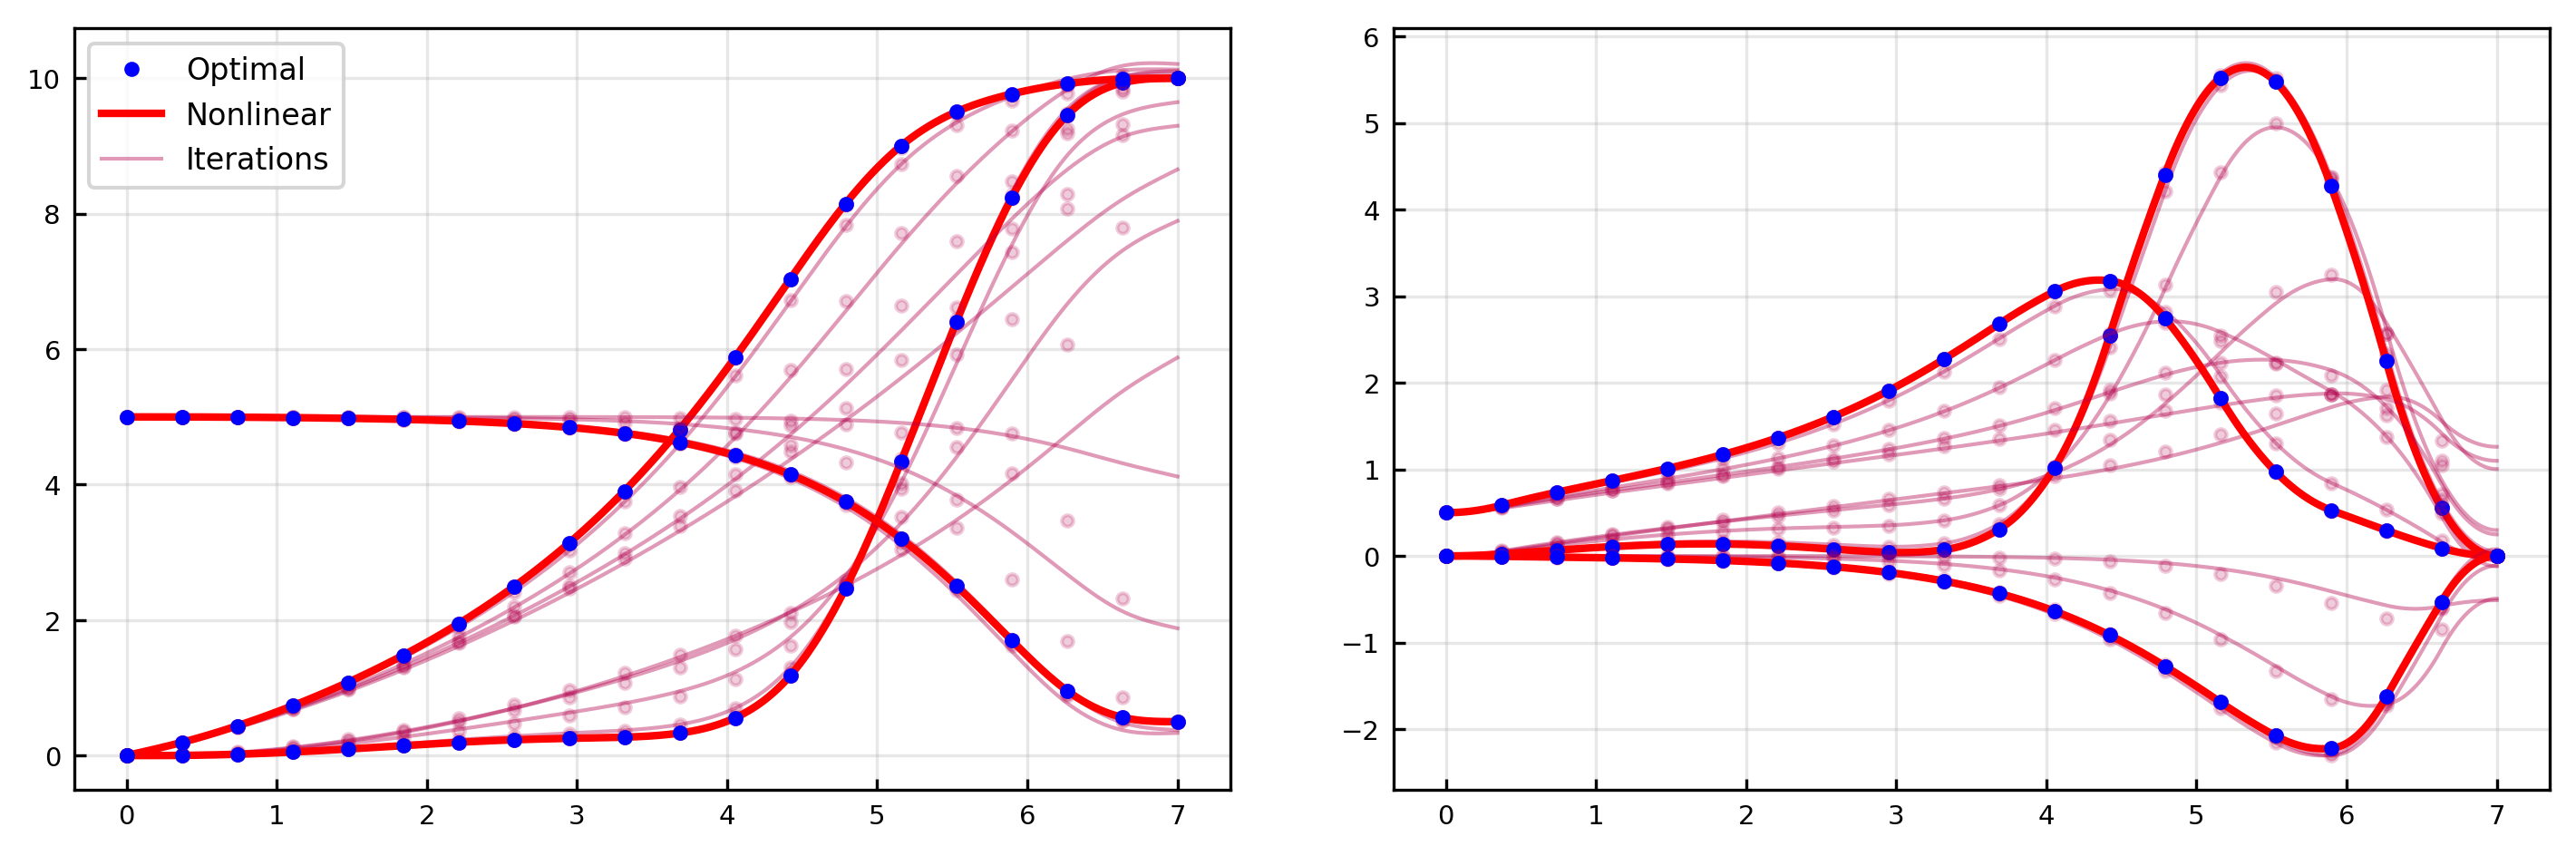

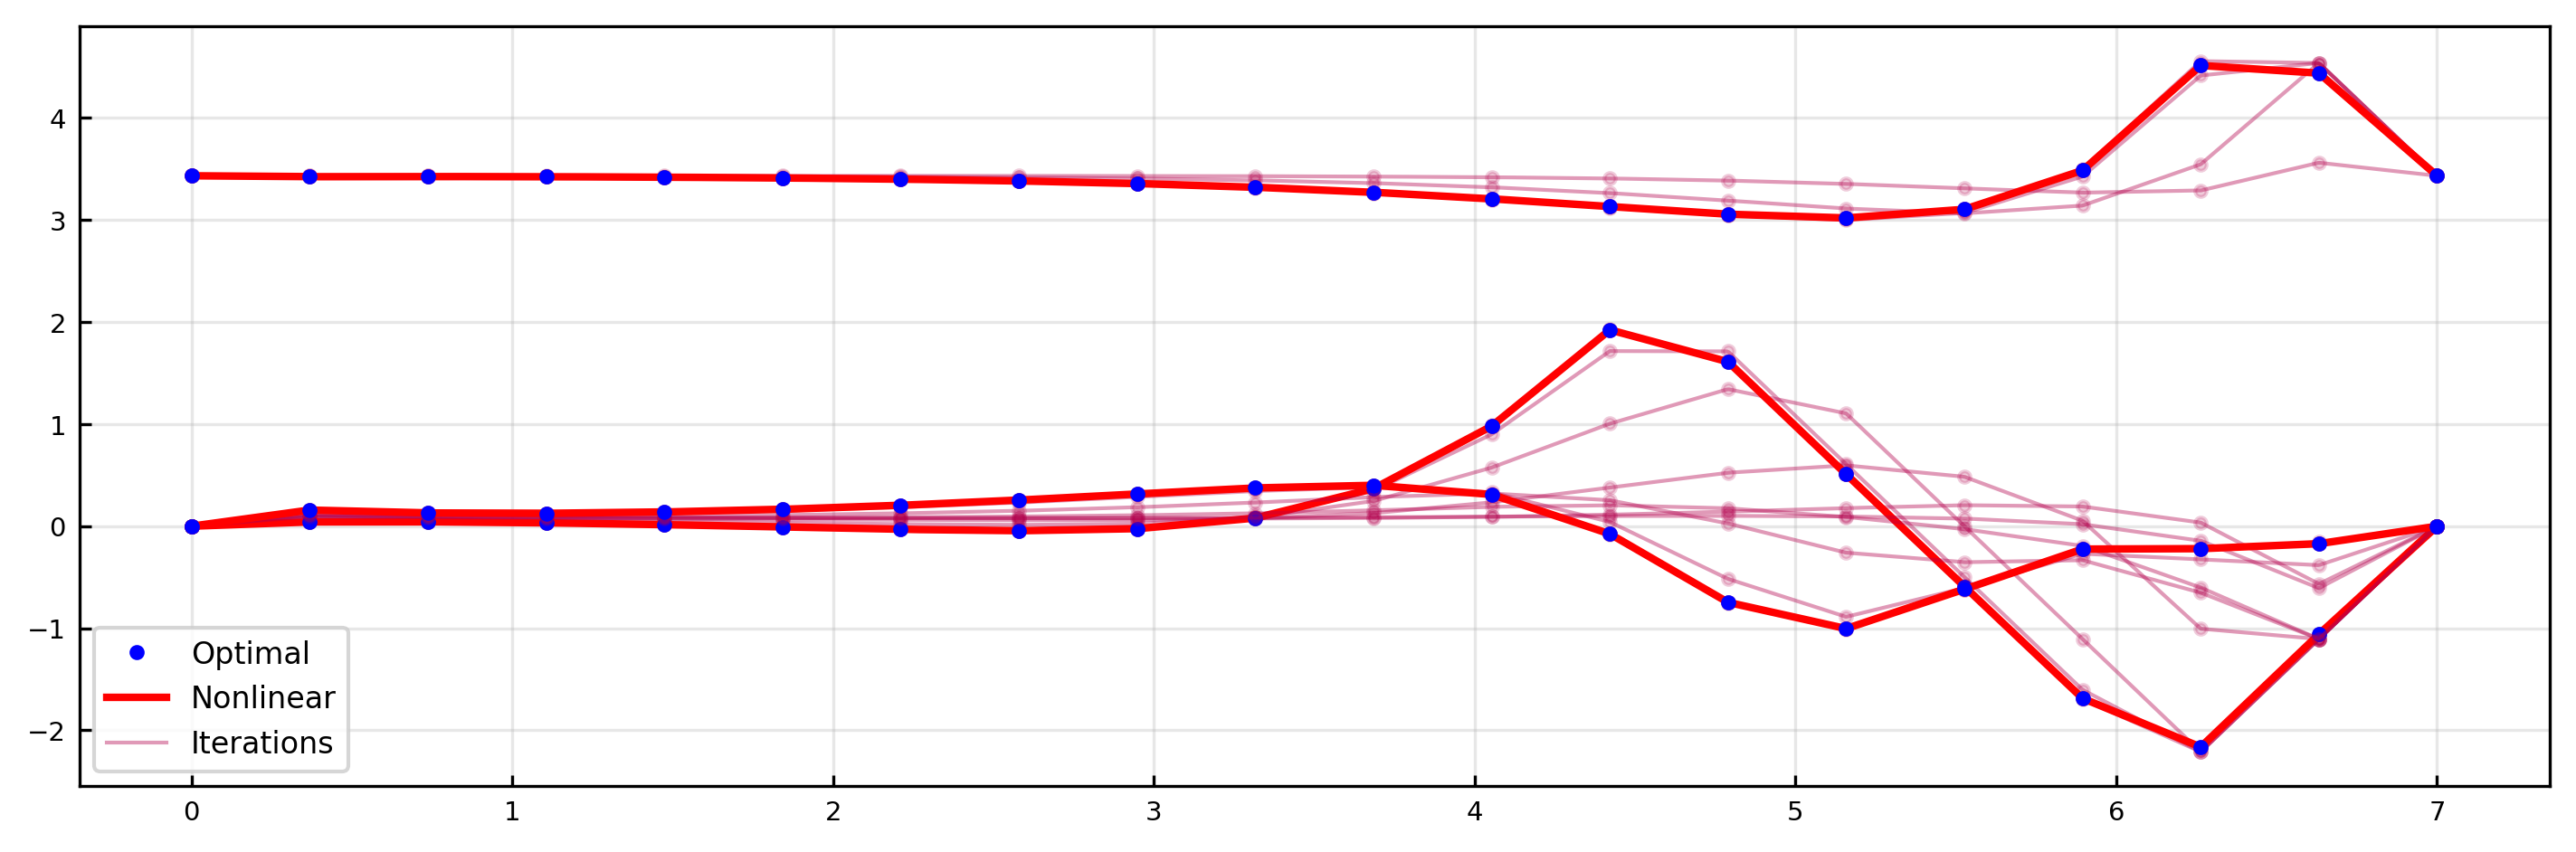

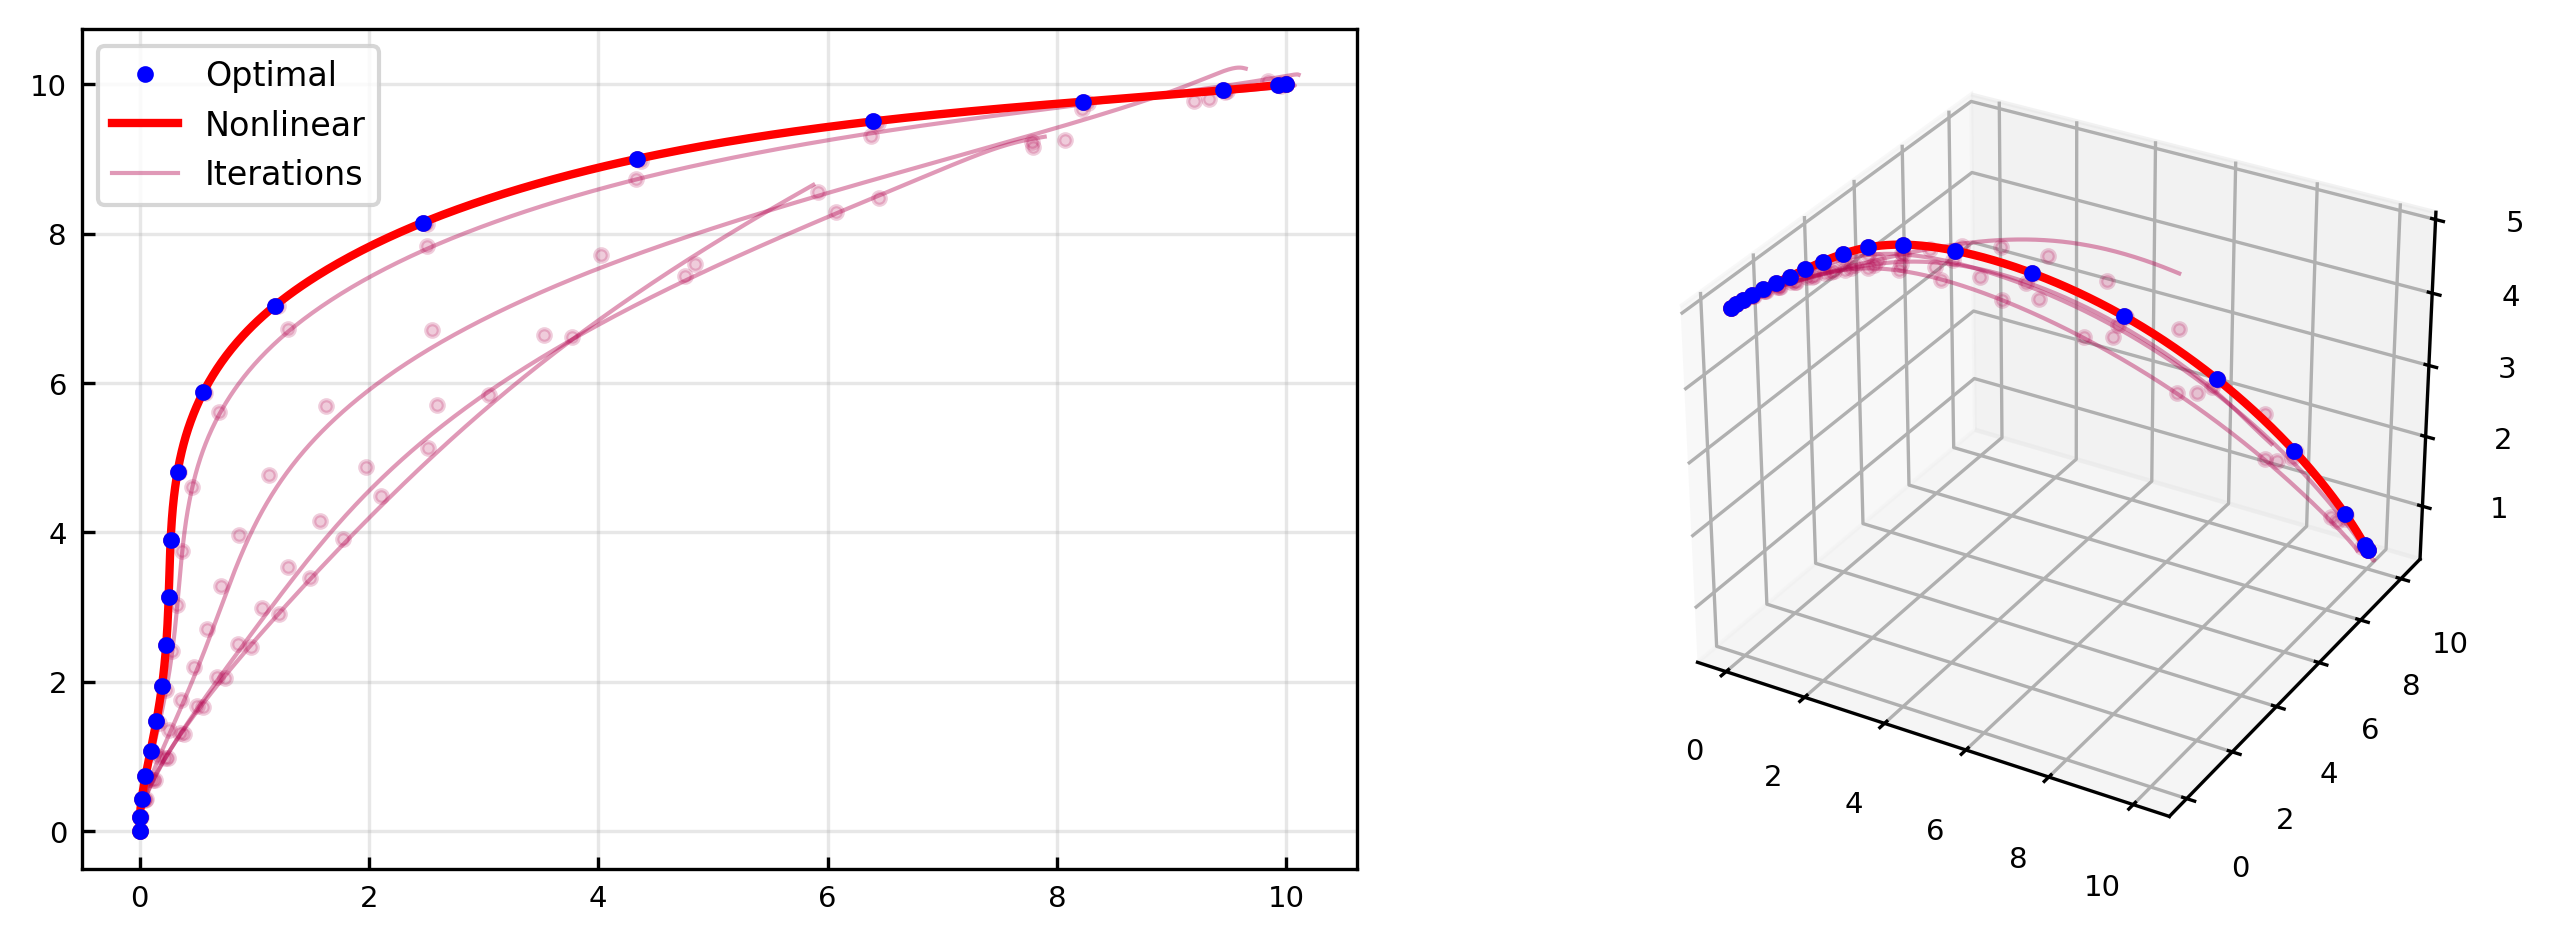

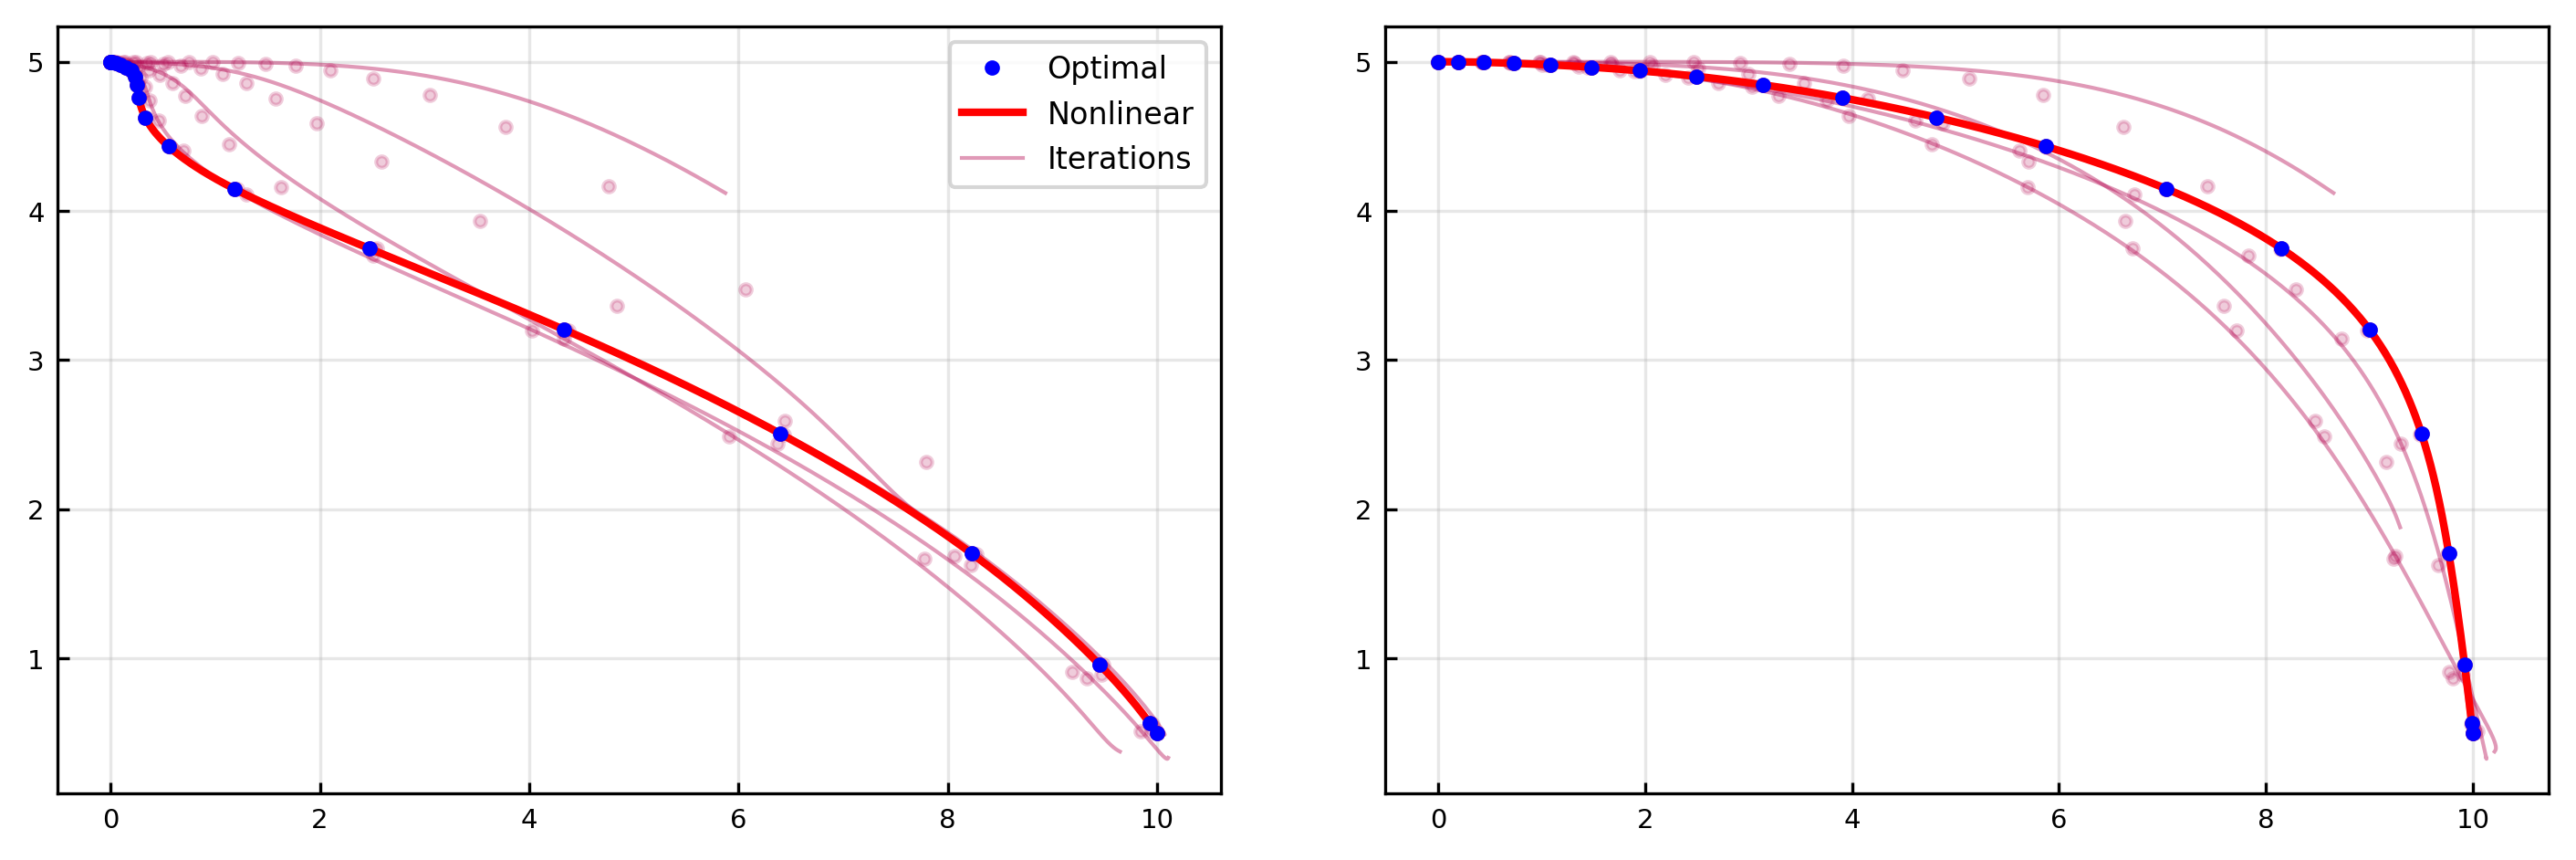

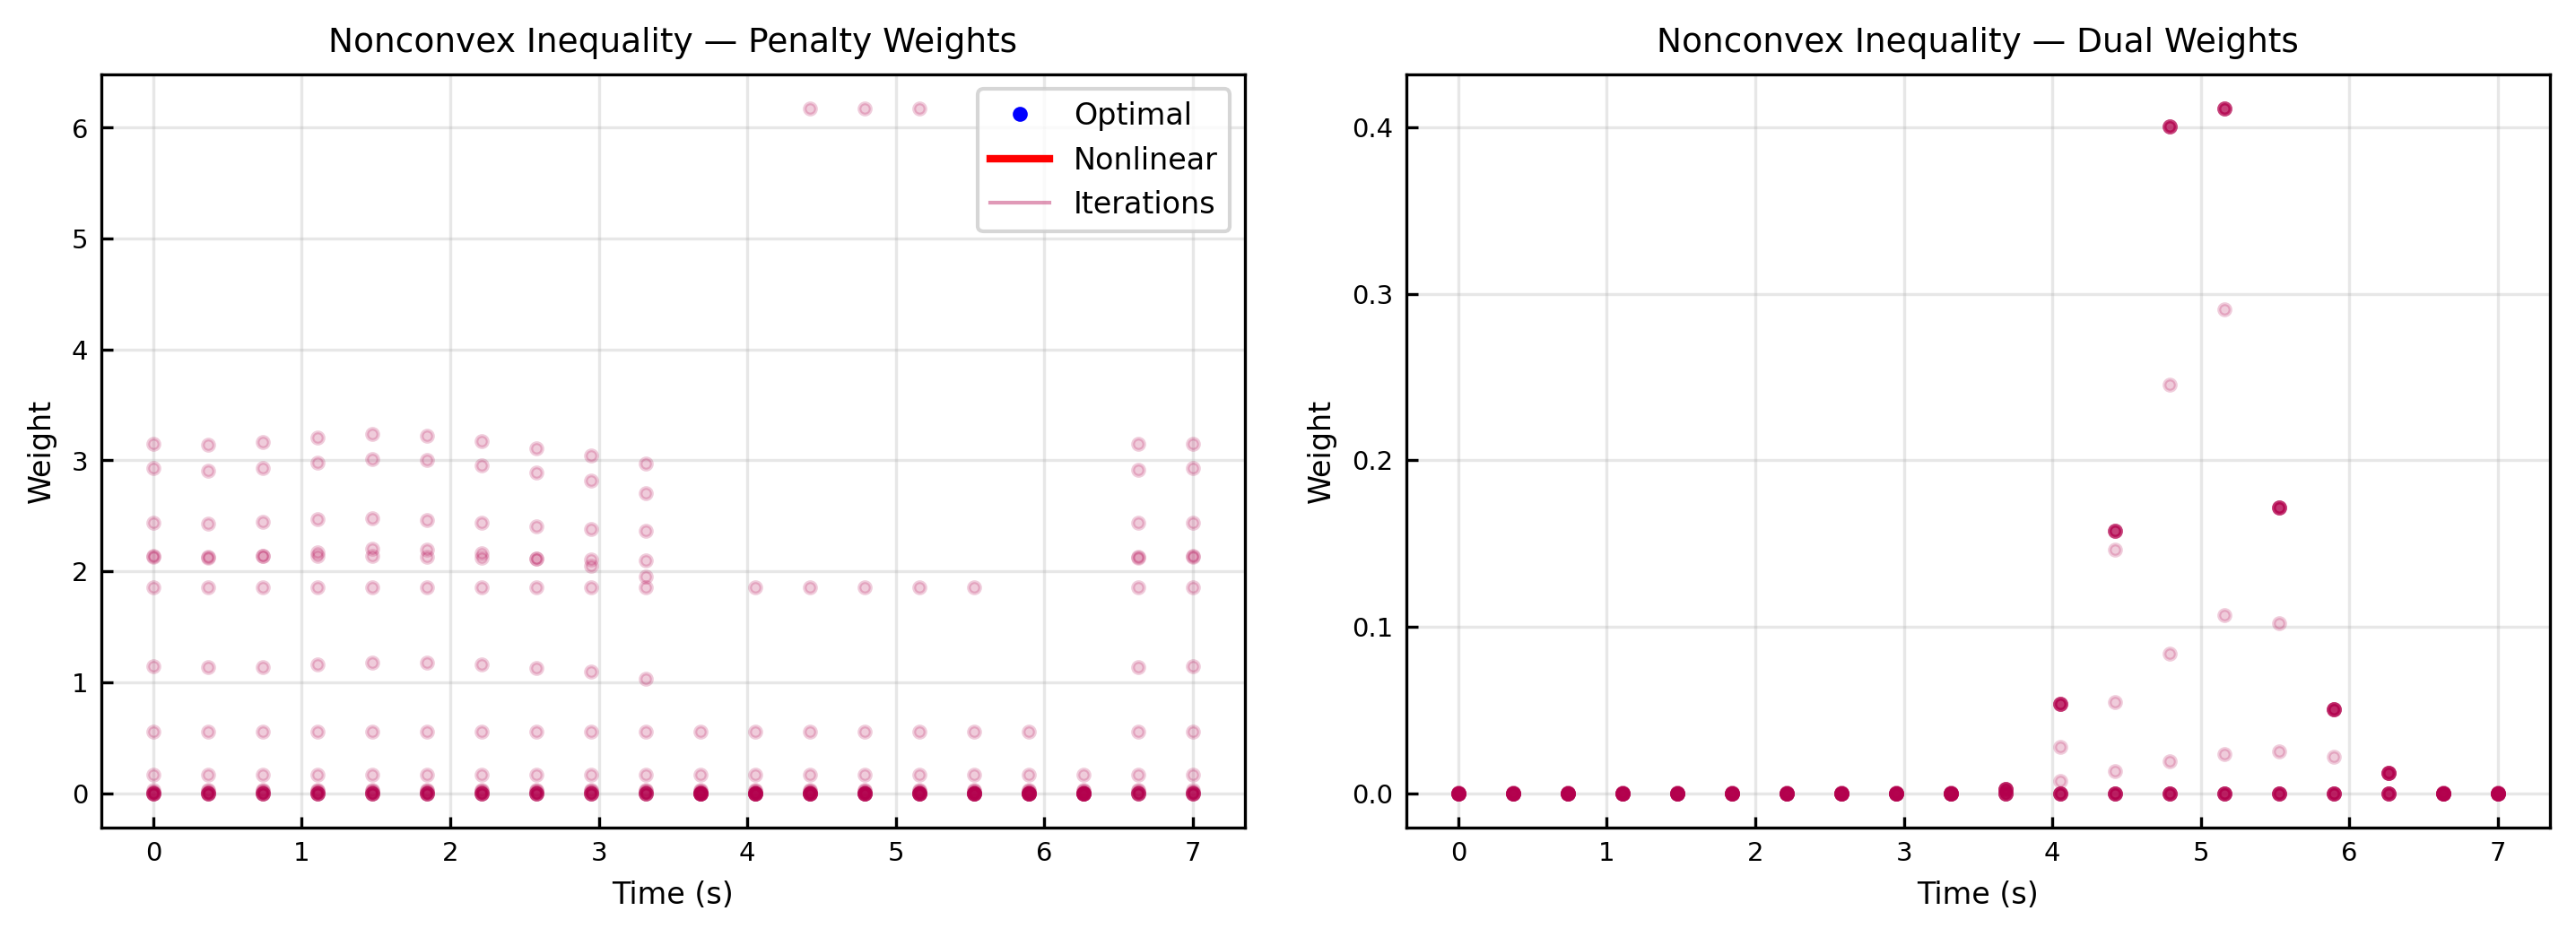

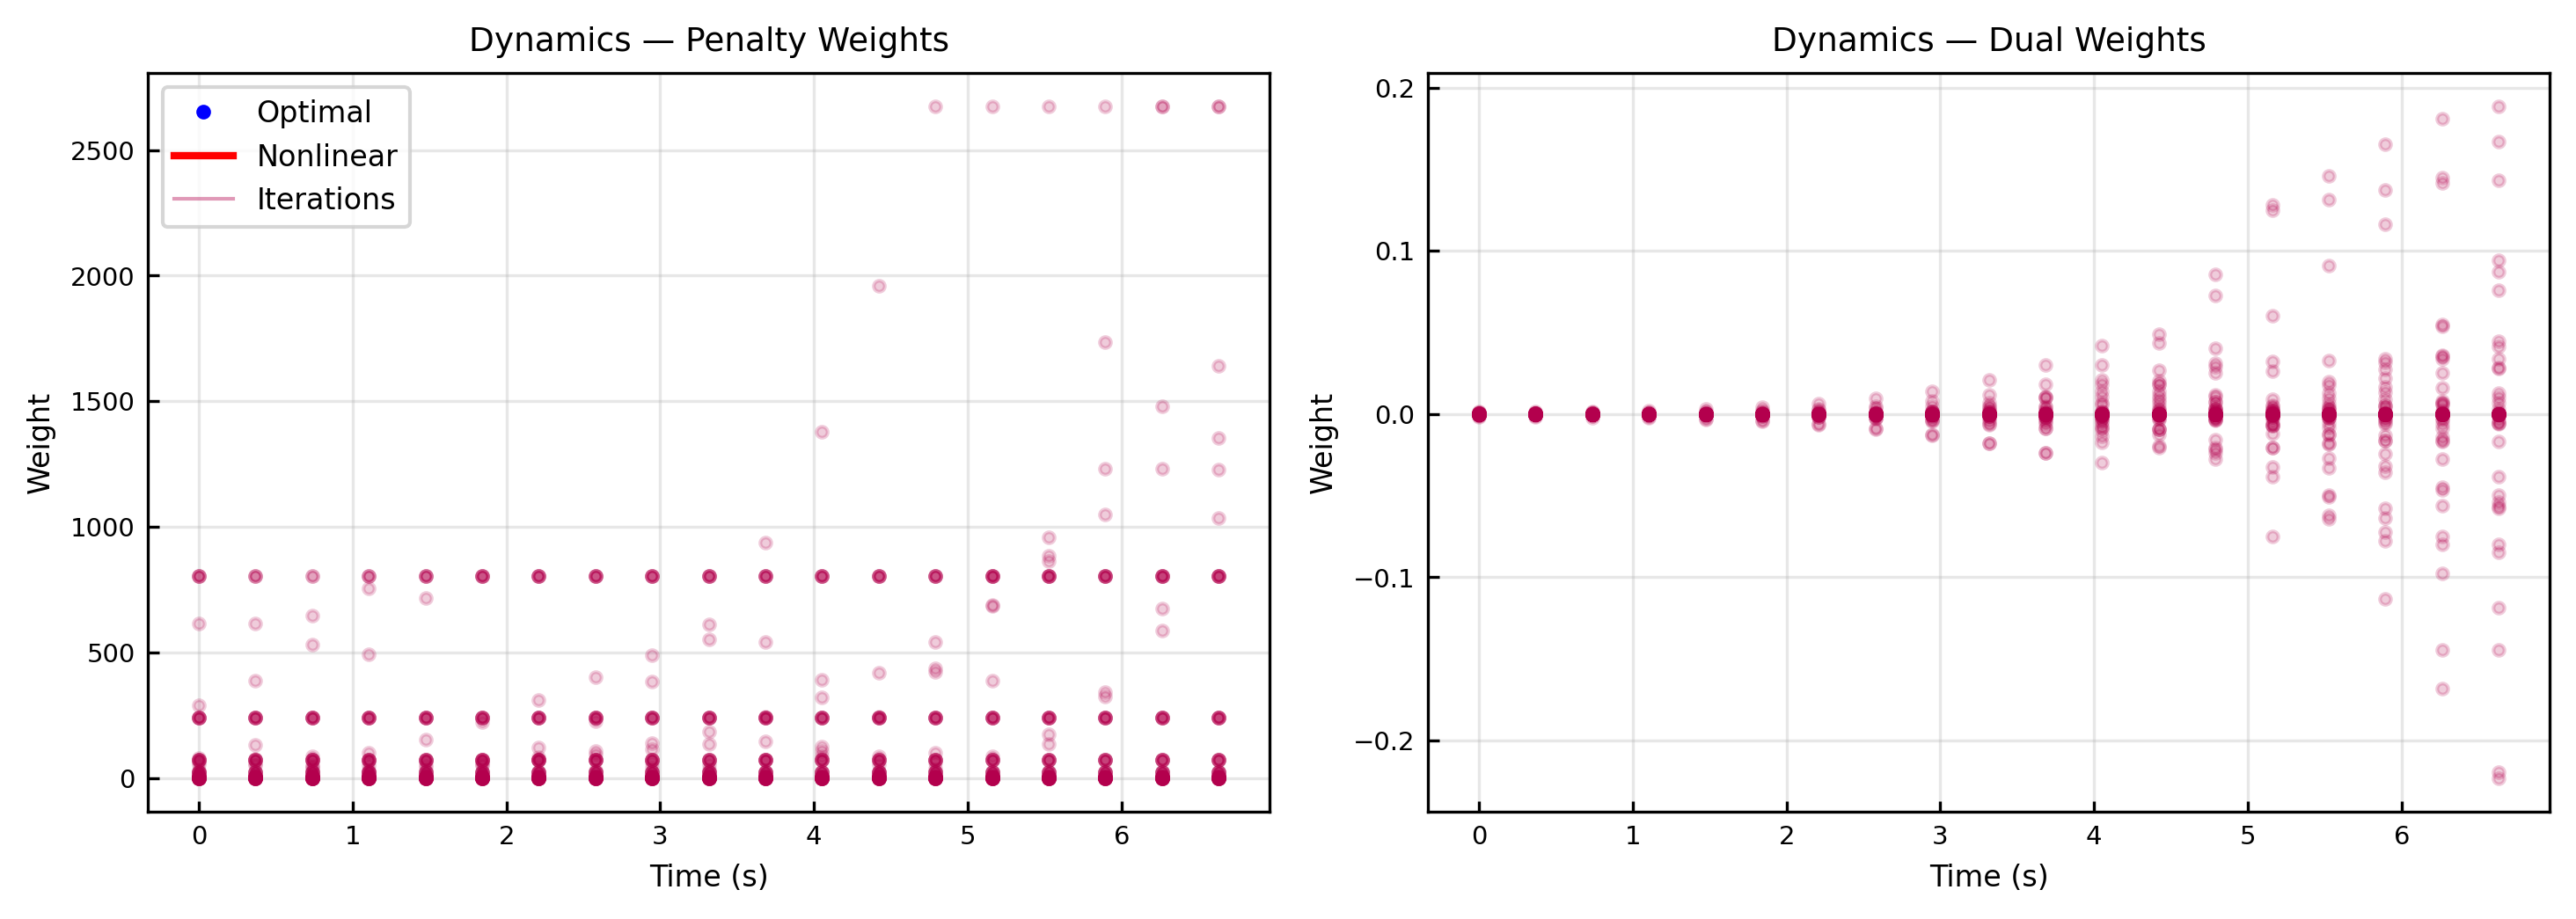

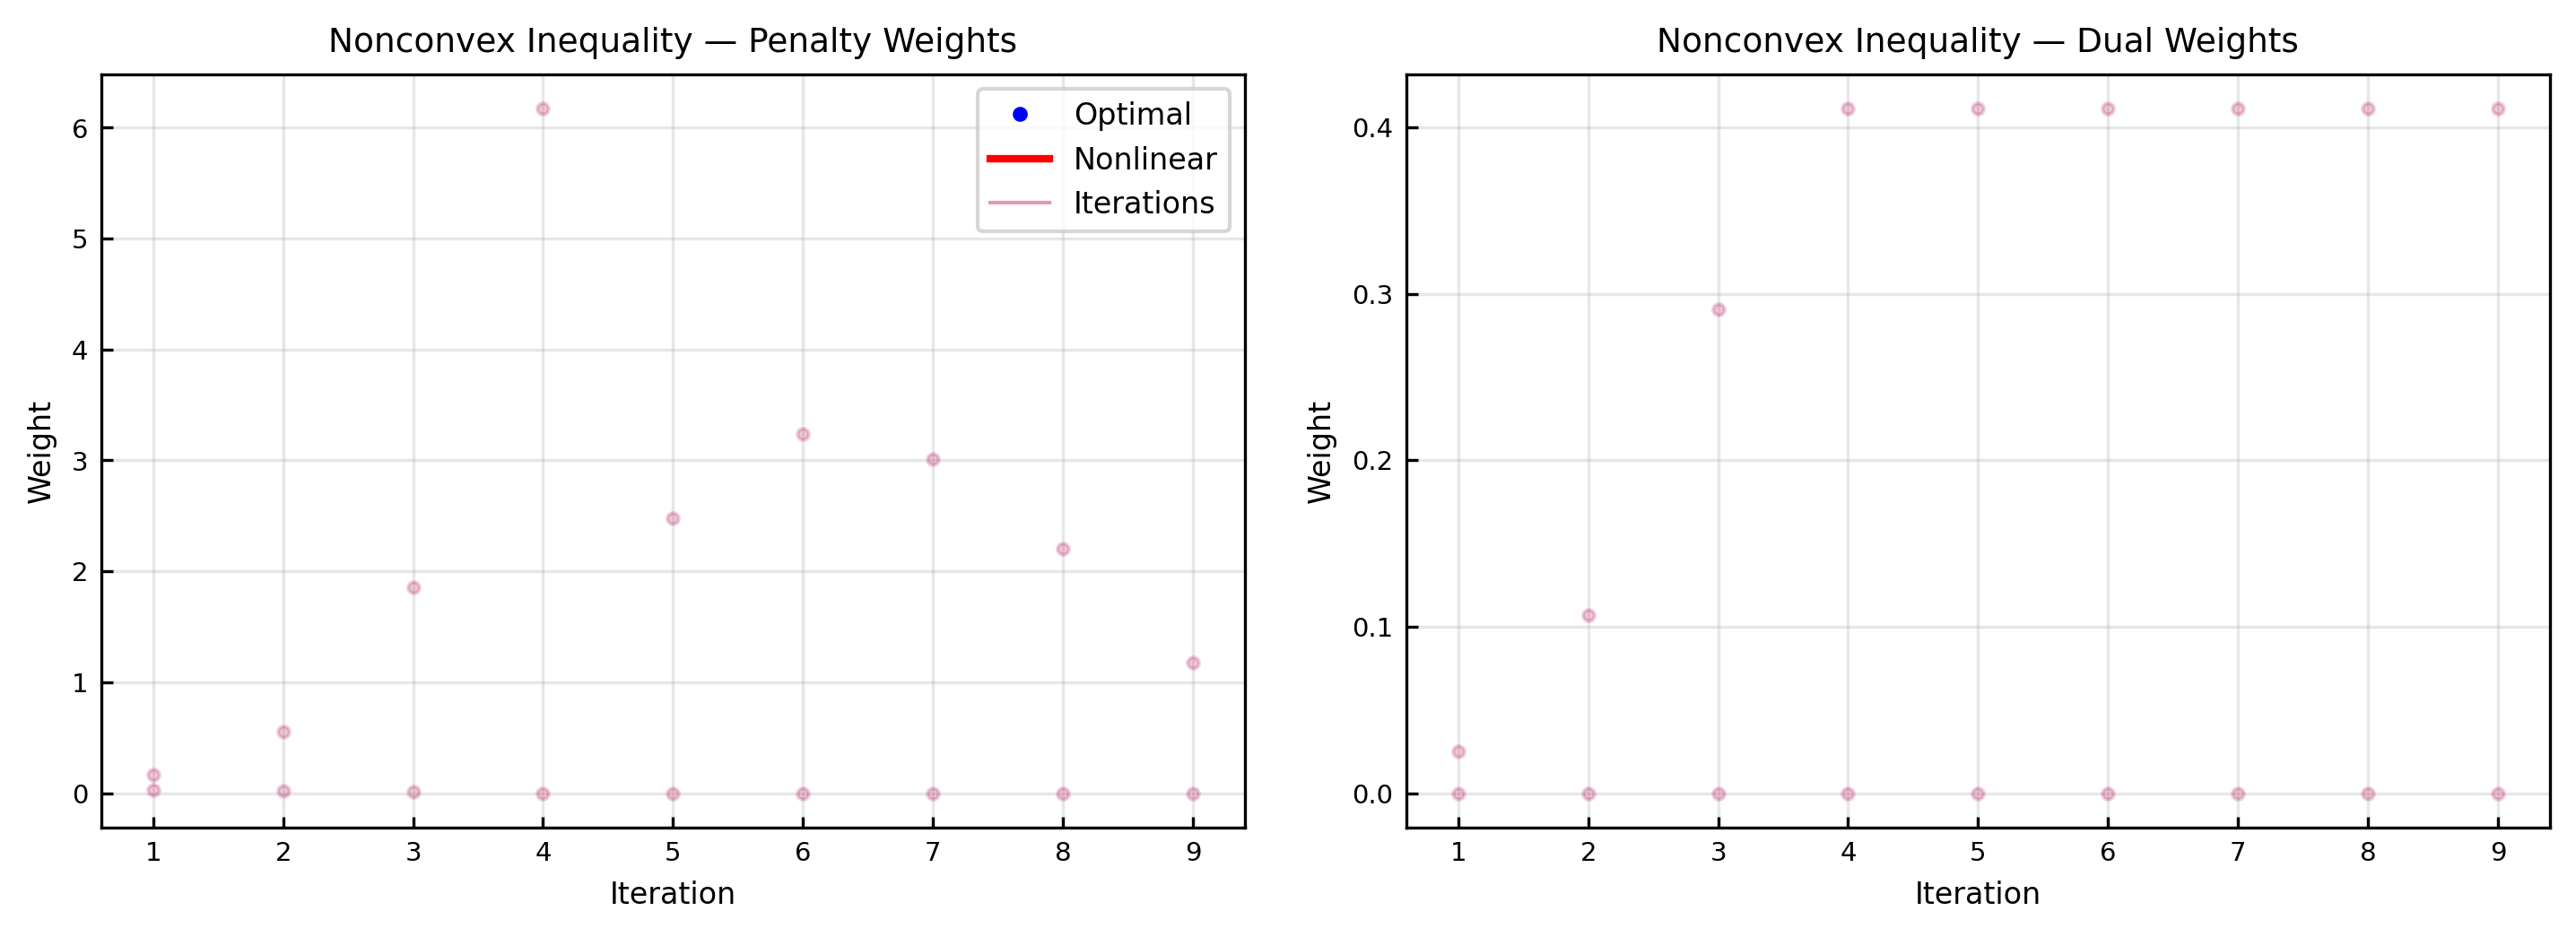

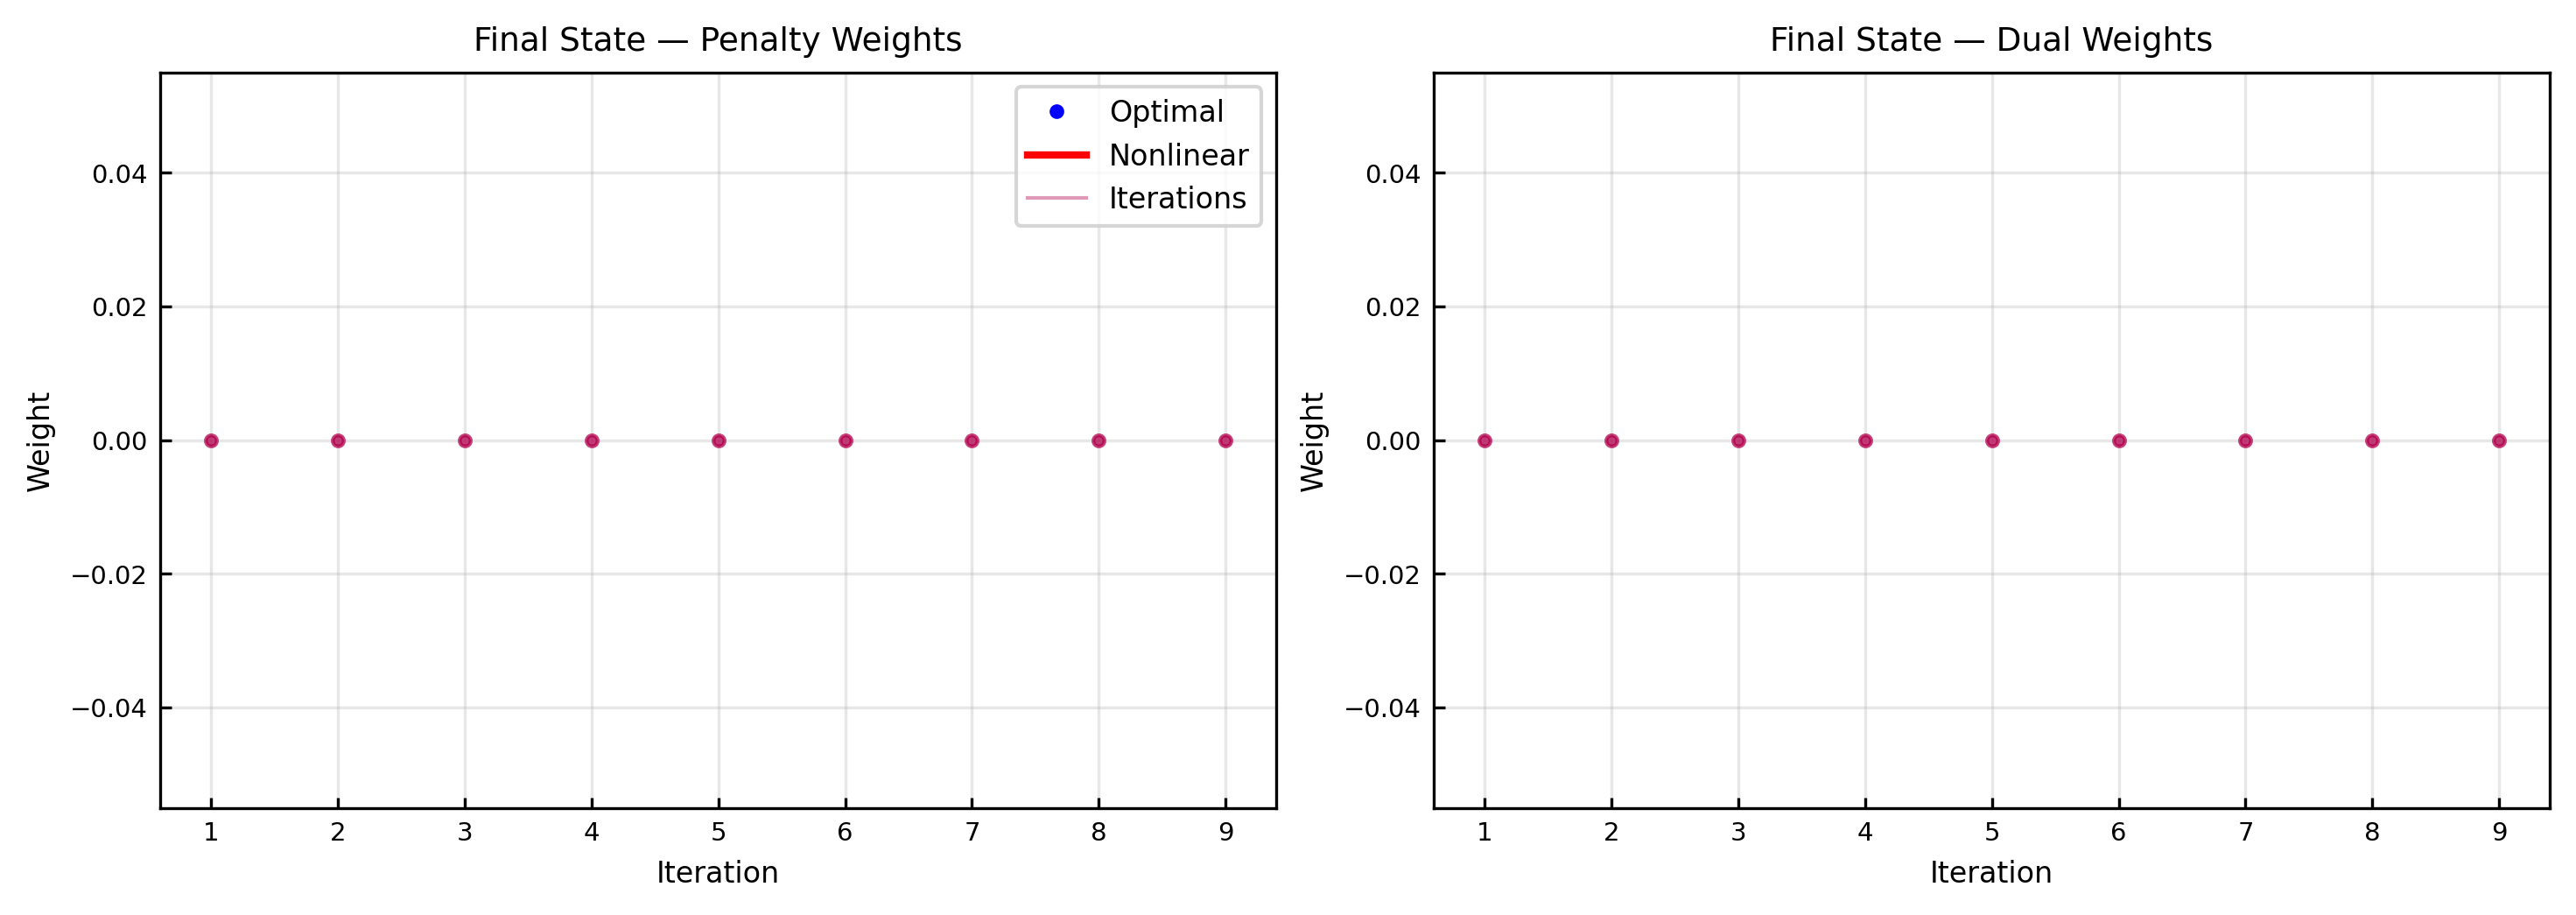

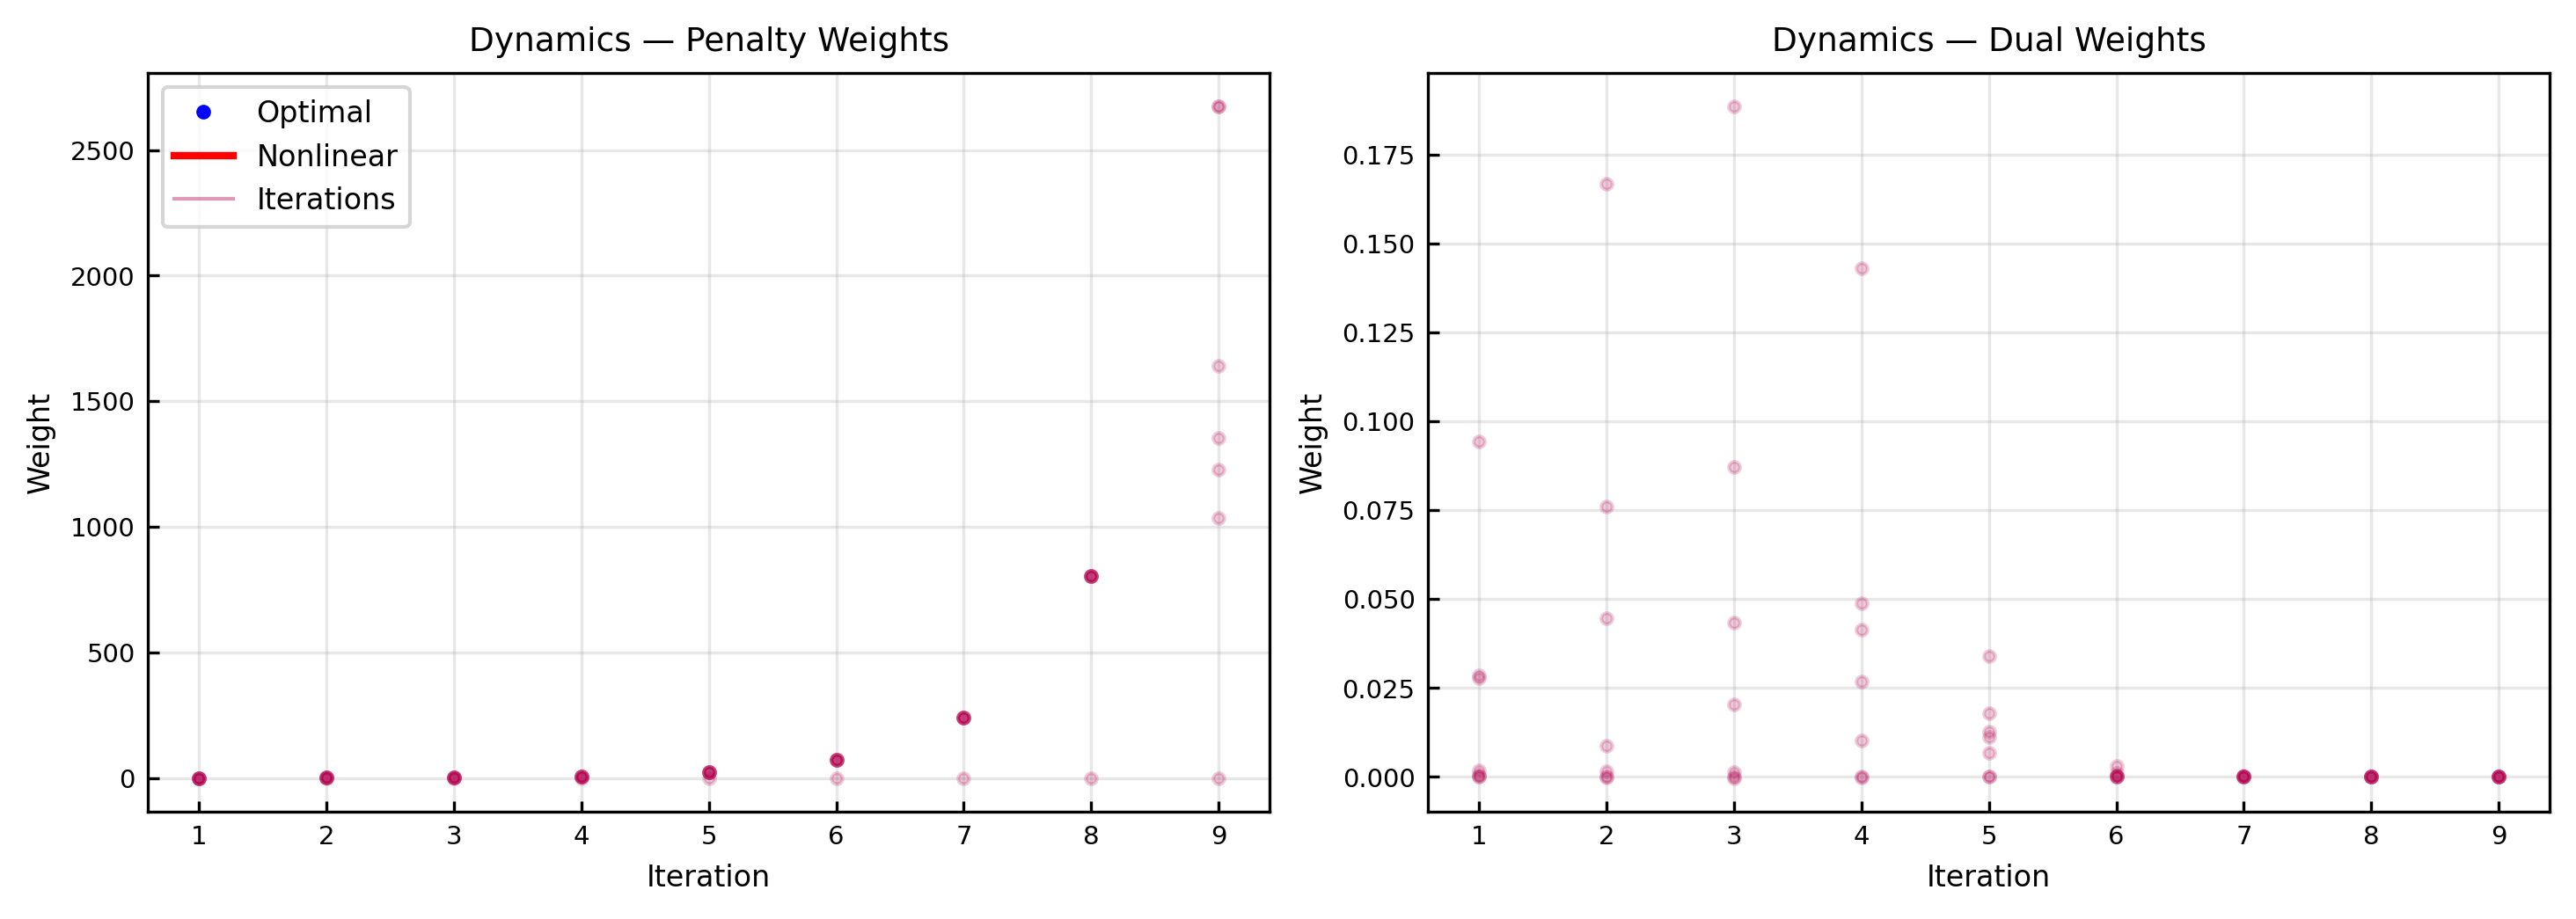

In [4]:
trajopt.plot(data, show_iters=True)

# PSEUDOSPECTRAL

In [5]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from trajopt.methods.scp.pseudospectral import flipped_radau_differential_operator
from trajopt.models.quadrotor_3dof import dynamics_jax

# ----------------------------------------------------------------
# Pull SCP solution (uniform FOH grid)
# ----------------------------------------------------------------
sol    = trajopt.solution
params = trajopt.problem.params
fcns   = trajopt.problem.fcns

t_opt  = np.asarray(sol['t_opt']).reshape(-1)   # (N+1,)
x_opt  = np.asarray(sol['x_opt'])                # (N+1, nx)
u_opt  = np.asarray(sol['u_opt'])                # (N,   nu)

t0     = t_opt[0]
tf     = t_opt[-1]
x0     = x_opt[0, :]

# ----------------------------------------------------------------
# Build fLGR nodes for N collocation points
# ----------------------------------------------------------------
N_scp   = len(t_opt) - 1   # SCP resolution
N       = 20 * N_scp

tau, etau, w, D = flipped_radau_differential_operator(N)

# Map tau in [-1,1] -> physical time
t_etau  = 0.5 * (tf - t0) * (etau) + 0.5 * (tf + t0)   # (N+1,) — includes t0
t_tau   = 0.5 * (tf - t0) * (tau) + 0.5 * (tf + t0)  # (N,)   — collocation nodes only

# ----------------------------------------------------------------
# Interpolate u_opt (FOH) onto etau/tau time grid
# ----------------------------------------------------------------
def interp_u_foh(t_query, t_grid, u_grid):
    """First-order hold: linearly interpolate between u_grid[k] and u_grid[k+1]."""
    idx   = np.searchsorted(t_grid[:-1], t_query, side='right') - 1
    idx   = np.clip(idx, 0, len(u_grid) - 2)

    t_k   = t_grid[idx]
    t_kp  = t_grid[idx + 1]
    u_k   = u_grid[idx]
    u_kp  = u_grid[idx + 1]

    a = (t_kp - t_query) / (t_kp - t_k)   # weight on k
    b = (t_query - t_k)  / (t_kp - t_k)   # weight on k+1

    return a * u_k + b * u_kp

u_etau = np.array([interp_u_foh(t, t_opt, u_opt) for t in t_etau])  # (N+1, nu)
u_tau  = np.array([interp_u_foh(t, t_opt, u_opt) for t in t_tau ])  # (N,   nu)

# ----------------------------------------------------------------
# Re-propagate dynamics with solve_ivp evaluated at etau nodes
# ----------------------------------------------------------------
def ode(t, x):
    u = interp_u_foh(t, t_opt, u_opt)
    return np.array(dynamics_jax(t, jnp.array(x), jnp.array(u), params, fcns))

ivp_sol = solve_ivp(
    ode,
    (t0, tf),
    x0,
    method       = "RK45",
    t_eval       = t_etau,
    dense_output = True,
    rtol         = 1e-10,
    atol         = 1e-12,
)
assert ivp_sol.success, f"IVP failed: {ivp_sol.message}"

X = ivp_sol.y.T   # (N+1, nx) — state at etau nodes

# ----------------------------------------------------------------
# LHS: pseudospectral derivative  D @ X  (scaled to physical time)
# ----------------------------------------------------------------
scale       = 2 / (tf - t0) 
X_dot_ps    = scale * (D @ X)         # (N, nx)

# ----------------------------------------------------------------
# RHS: f(x, u) at collocation nodes tau
# ----------------------------------------------------------------
X_tau = X[1:, :]    # drop initial node -> collocation nodes

nx = X.shape[1]
X_dot_f = np.array([
    np.array(dynamics_jax(t_tau[k], jnp.array(X_tau[k]), jnp.array(u_tau[k]), params, fcns))
    for k in range(N)
])                  # (N, nx)

# ----------------------------------------------------------------
# Defect
# ----------------------------------------------------------------
defect = X_dot_ps - X_dot_f   # (N, nx)

state_labels = ["x", "y", "z", "vx", "vy", "vz"]

print(f"{'State':<8}  {'Max |defect|':>14}  {'Mean |defect|':>14}")
print("-" * 42)
for i, label in enumerate(state_labels):
    print(f"{label:<8}  {np.max(np.abs(defect[:, i])):>14.6e}  {np.mean(np.abs(defect[:, i])):>14.6e}")
print(f"\n{'TOTAL':<8}  {np.max(np.abs(defect)):>14.6e}")

State       Max |defect|   Mean |defect|
------------------------------------------
x           1.248566e-04    5.439886e-06
y           4.685500e-05    3.703669e-06
z           4.783812e-05    2.260358e-06
vx          1.354155e-02    8.153647e-04
vy          1.182636e-02    3.406622e-04
vz          9.222987e-03    5.202752e-04

TOTAL       1.354155e-02


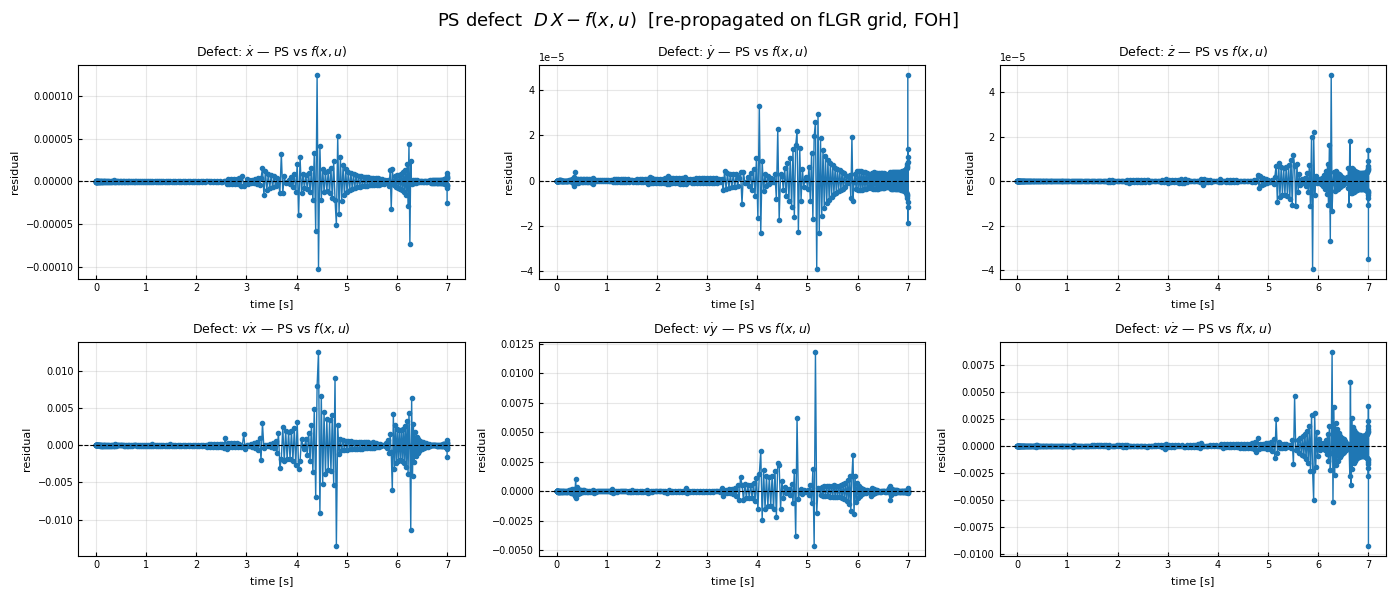

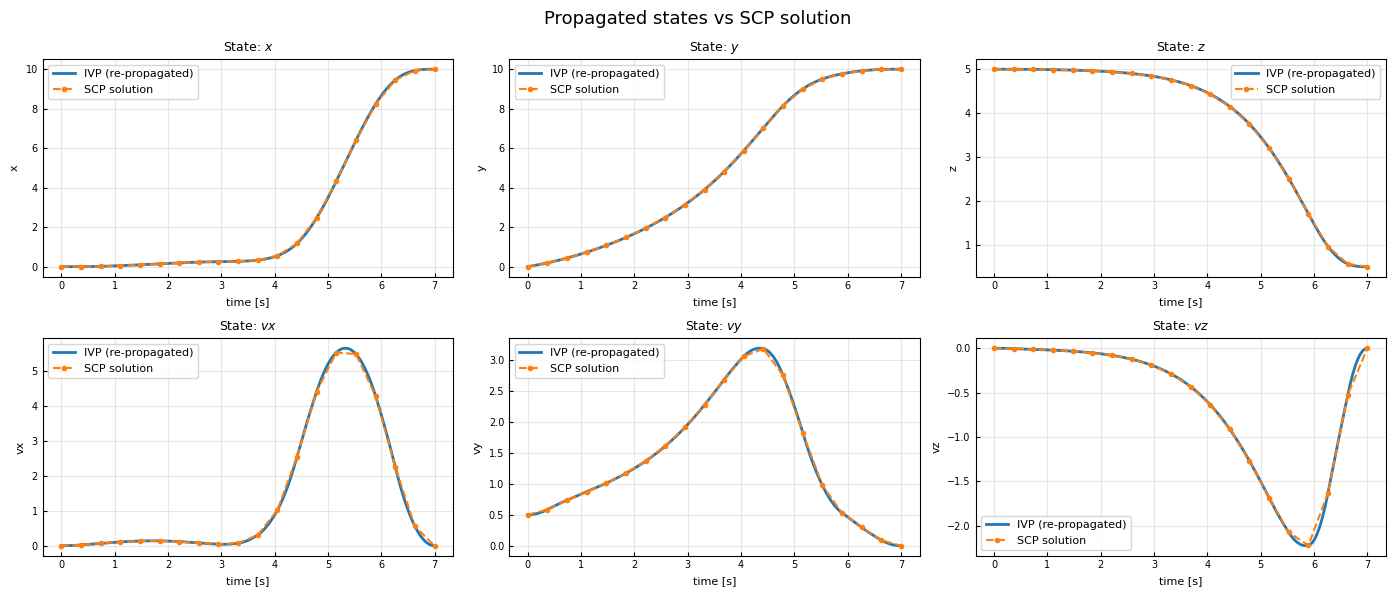

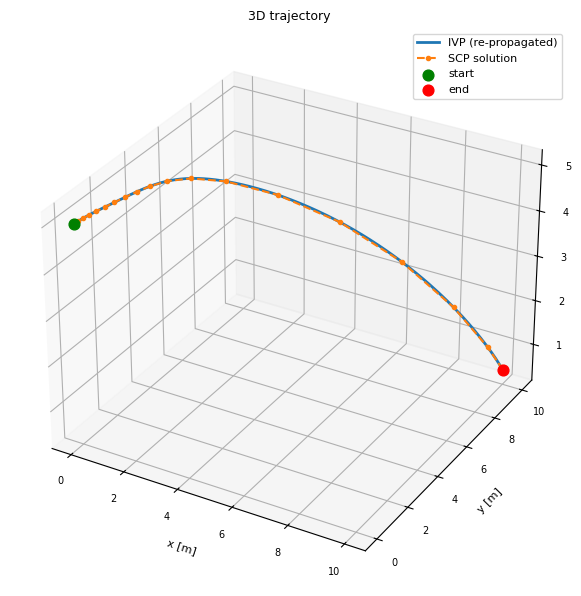

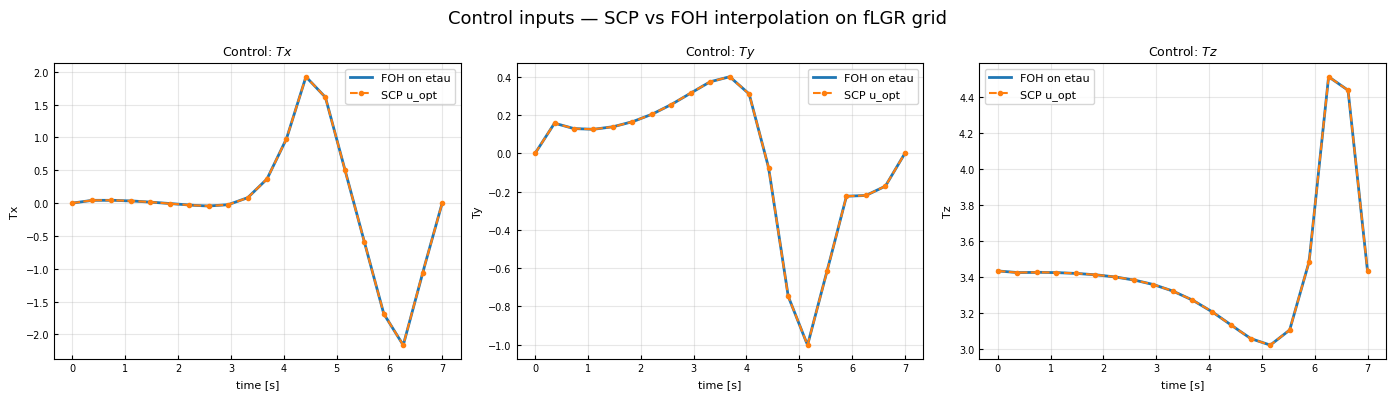

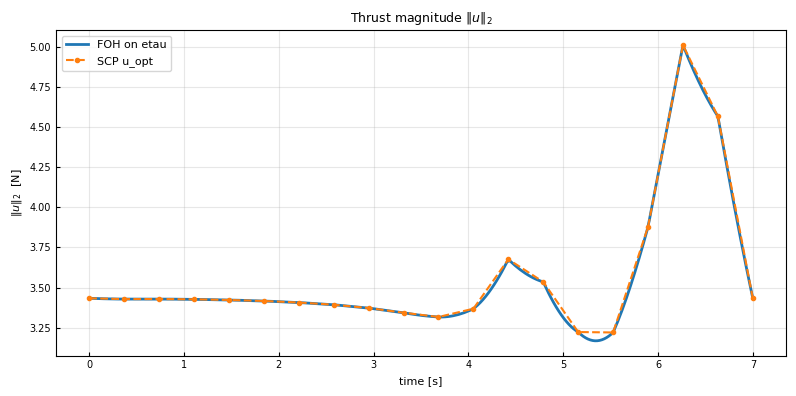

In [6]:
# ----------------------------------------------------------------
# Plot
# ----------------------------------------------------------------
fig, axs = plt.subplots(2, 3, figsize=(14, 6))
axs = axs.flatten()

for i, label in enumerate(state_labels):
    axs[i].plot(t_tau, defect[:, i], marker="o", ms=3)
    axs[i].axhline(0, color="k", lw=0.8, ls="--")
    axs[i].set_title(f"Defect: $\\dot{{{label}}}$ — PS vs $f(x,u)$")
    axs[i].set_xlabel("time [s]")
    axs[i].set_ylabel("residual")
    axs[i].grid(True, alpha=0.3)

plt.suptitle("PS defect  $D\\,X - f(x,u)$  [re-propagated on fLGR grid, FOH]", fontsize=13)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
# Plot propagated states at etau nodes
# ----------------------------------------------------------------
fig, axs = plt.subplots(2, 3, figsize=(14, 6))
axs = axs.flatten()

for i, label in enumerate(state_labels):
    axs[i].plot(t_etau, X[:, i],    lw=2,  label="IVP (re-propagated)")
    axs[i].plot(t_opt,  x_opt[:, i], lw=1.5, ls="--", marker="o", ms=3, label="SCP solution")
    axs[i].set_title(f"State: ${label}$")
    axs[i].set_xlabel("time [s]")
    axs[i].set_ylabel(label)
    axs[i].legend(fontsize=8)
    axs[i].grid(True, alpha=0.3)

plt.suptitle("Propagated states vs SCP solution", fontsize=13)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
# Plot 3D trajectory
# ----------------------------------------------------------------
fig = plt.figure(figsize=(7, 6))
ax  = fig.add_subplot(111, projection='3d')

ax.plot(X[:, 0],      X[:, 1],      X[:, 2],      lw=2,        label="IVP (re-propagated)")
ax.plot(x_opt[:, 0],  x_opt[:, 1],  x_opt[:, 2],  lw=1.5, ls="--", marker="o", ms=3, label="SCP solution")

ax.scatter(*X[0,  :3], color="green", s=60, zorder=5, label="start")
ax.scatter(*X[-1, :3], color="red",   s=60, zorder=5, label="end")

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_title("3D trajectory")
ax.legend()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
# Plot control inputs
# ----------------------------------------------------------------
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

u_labels = ["Tx", "Ty", "Tz"]
for i, label in enumerate(u_labels):
    axs[i].plot(t_etau, u_etau[:, i], lw=2, label="FOH on etau")
    axs[i].plot(t_opt, u_opt[:, i], lw=1.5, ls="--", marker="o", ms=3, label="SCP u_opt")  # u_opt is (N+1,) for FOH
    axs[i].set_title(f"Control: ${label}$")
    axs[i].set_xlabel("time [s]")
    axs[i].set_ylabel(label)
    axs[i].legend(fontsize=8)
    axs[i].grid(True, alpha=0.3)

plt.suptitle("Control inputs — SCP vs FOH interpolation on fLGR grid", fontsize=13)
plt.tight_layout()
plt.show()

# ...existing code...

# ----------------------------------------------------------------
# Plot thrust magnitude (2-norm)
# ----------------------------------------------------------------
T_mag_etau = np.linalg.norm(u_etau, axis=1)   # (N+1,)
T_mag_opt  = np.linalg.norm(u_opt,  axis=1)   # (N+1,)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_etau, T_mag_etau, lw=2,        label="FOH on etau")
ax.plot(t_opt,  T_mag_opt,  lw=1.5, ls="--", marker="o", ms=3, label="SCP u_opt")
ax.set_title("Thrust magnitude $\\|u\\|_2$")
ax.set_xlabel("time [s]")
ax.set_ylabel("$\\|u\\|_2$  [N]")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()